## Project Overview: Demand Forecasting for a Milk Company

This project focuses on building a demand forecasting model for a milk company that deals with the production, processing, and distribution of perishable dairy products. Due to the short shelf life of milk, accurate forecasting is essential to reduce waste and ensure efficient inventory and supply chain management.

## Objective

The goal is to predict future demand at the customer and item level across monthly, quarterly, and yearly intervals. Using historical sales data, we aim to analyze patterns, extract insights, and develop a predictive model to support informed business decisions.

-----------------------------------------------------------------------------------------------

In [42]:
# import warnings
import warnings
warnings.filterwarnings('ignore')

#importing all necessary libraries

import pandas as pd,numpy as np
import matplotlib.pyplot as plt,seaborn as sns


### 1. Reading and Understanding data

In [43]:
# Load and inspect milk dataset and checking the first 5 rows using head()
milk_data = pd.read_csv('milk_sales_datav1.csv')
milk_data.head()

,Date,Item Code,Route Code,Customer Code,Sales Quantity,Stales Quantity
0,01-01-2022,ITEM09,ROUTE17,CUST269,456,0
1,01-01-2022,ITEM02,ROUTE12,CUST269,233,32
2,01-01-2022,ITEM03,ROUTE19,CUST269,560,138
3,01-01-2022,ITEM04,ROUTE08,CUST074,161,30
4,01-01-2022,ITEM08,ROUTE04,CUST290,298,36


In [44]:
# checking the rows and columns of dataset
milk_data.shape

(431801, 6)

Dataset Overview:
Rows: 431,801

Columns: 6

Date Range: Starts from 01-01-2022 (will confirm full range during EDA)

In [45]:
# Displaying the basic information of data
milk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431801 entries, 0 to 431800
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Date             431801 non-null  object
 1   Item Code        431801 non-null  object
 2   Route Code       431801 non-null  object
 3   Customer Code    431801 non-null  object
 4   Sales Quantity   431801 non-null  int64 
 5   Stales Quantity  431801 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 19.8+ MB


Key Columns:

Date (currently in object format). need to convert in datetime format

Item Code, Route Code, Customer Code (categorical identifiers)

Sales Quantity (main metric to forecast)

Stales Quantity (quantity wasted or unsold)

--------------------------------------------------------------------------------

### Task 1 - EDA (Exploratory Data Analysis)

  Task 1.a). Perform Data Analysis and Derive Initial Judgments

  Missing values

  Date parsing

  Summary statistics

In [46]:
# Checking missing values
print(milk_data.isnull().sum())

# checking duplicate values
print(milk_data.duplicated().sum())


Date               0
Item Code          0
Route Code         0
Customer Code      0
Sales Quantity     0
Stales Quantity    0
dtype: int64
0


No missing values found in any column.

No duplicate rows detected.



In [47]:
# Data Cleaning and Initial Judgments
# Convert 'Date' to datetime
milk_data['Date'] = pd.to_datetime(milk_data['Date'], dayfirst=True)
milk_data['Total Quantity'] = milk_data['Sales Quantity'] + milk_data['Stales Quantity']
milk_data['Month'] = milk_data['Date'].dt.to_period('M')


# Check date range
date_range = (milk_data['Date'].min(), milk_data['Date'].max())

# Group by Date to analyze daily sales
daily_sales = milk_data.groupby('Date')[['Sales Quantity', 'Stales Quantity', 'Total Quantity']].sum().reset_index()

# Group by Month for trend visualization
monthly_summary = milk_data.groupby('Month')[['Sales Quantity', 'Stales Quantity', 'Total Quantity']].sum().reset_index()
monthly_summary['Month'] = monthly_summary['Month'].dt.to_timestamp()

# Show date range
print(f"Milk Data:\n{milk_data['Date'].head(3)}\n\n"
      f"Daily Sales:\n{daily_sales.head()}\n\n"
      f"Date Range:\n{date_range}")

Milk Data:
0   2022-01-01
1   2022-01-01
2   2022-01-01
Name: Date, dtype: datetime64[ns]

Daily Sales:
        Date  Sales Quantity  Stales Quantity  Total Quantity
0 2022-01-01          119704            10712          130416
1 2022-01-02           92157             8705          100862
2 2022-01-03           99281             9104          108385
3 2022-01-04          105597             9569          115166
4 2022-01-05          141269            12126          153395

Date Range:
(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))


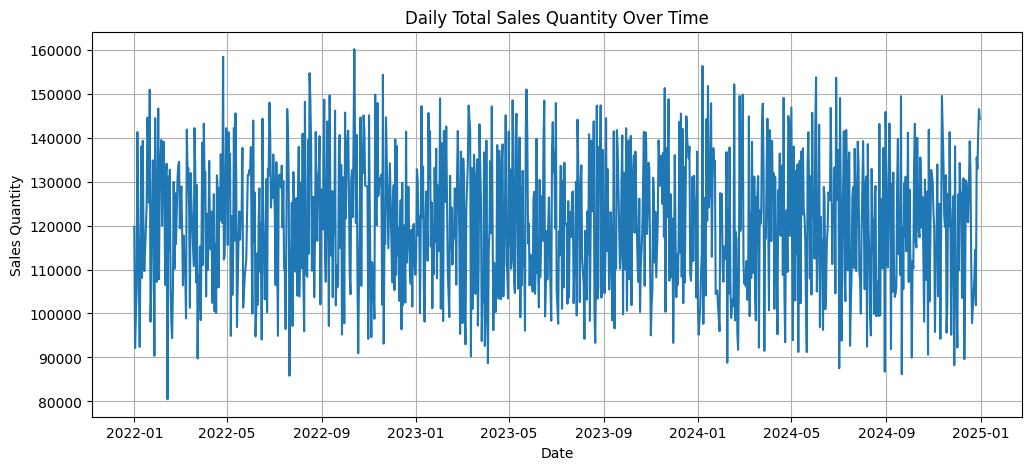

In [48]:
# Plot total daily sales
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales Quantity'])
plt.title('Daily Total Sales Quantity Over Time')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.grid()
plt.show()

Date Conversion and Overview:

- The dataset spans from 1st January 2022 to 31st December 2024.

- We've successfully converted the Date column into a proper datetime format.

- The plot above shows the daily total sales quantity trend, and we can observe.

- Regular sales patterns with fluctuations.

- Possible seasonality (will explore further).

- Some peaks and dips—potential holidays or anomalies.

Task 1. b). Identify trends,seasonality and correlations

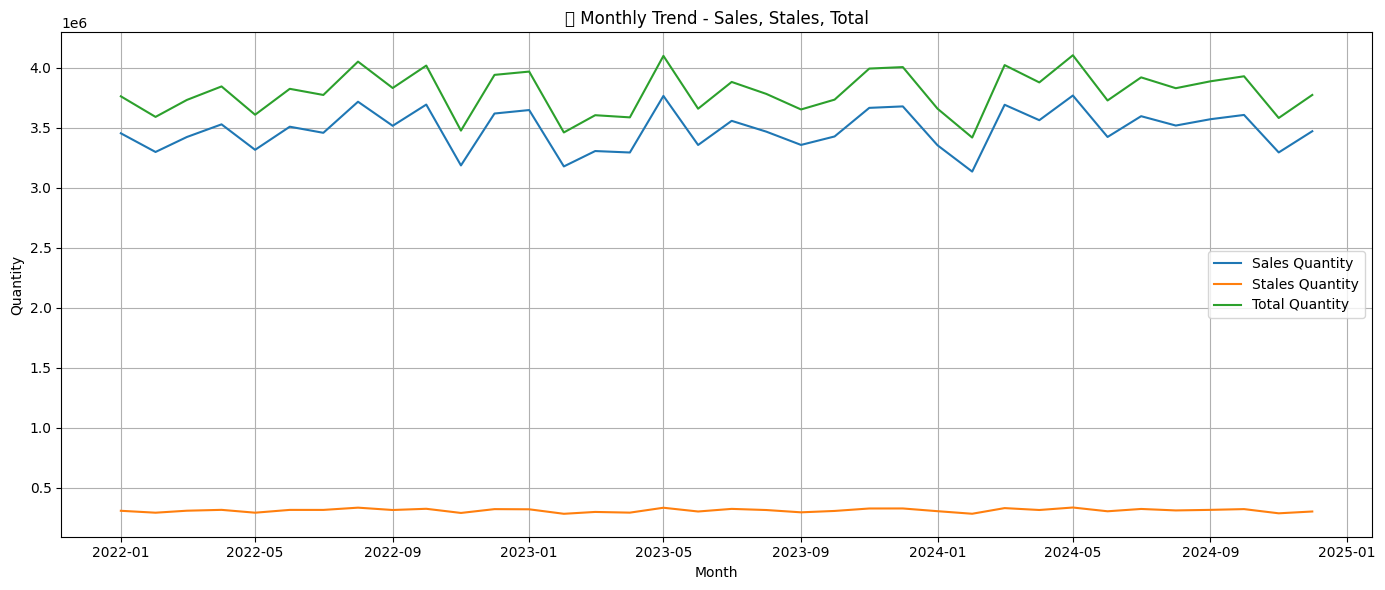

In [49]:
## Plotting monthly trends for sales, stales and total quantity
plt.figure(figsize=(14, 6))
plt.plot(monthly_summary['Month'], monthly_summary['Sales Quantity'], label='Sales Quantity')
plt.plot(monthly_summary['Month'], monthly_summary['Stales Quantity'], label='Stales Quantity')
plt.plot(monthly_summary['Month'], monthly_summary['Total Quantity'], label='Total Quantity')
plt.title("📊 Monthly Trend - Sales, Stales, Total")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


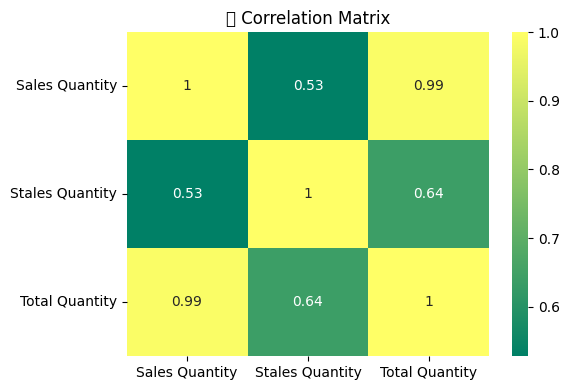

In [50]:
# Correlation heatmap for numerical fields
correlation_matrix = milk_data[['Sales Quantity', 'Stales Quantity', 'Total Quantity']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='summer')
plt.title("🔗 Correlation Matrix")
plt.tight_layout()
plt.show()

Check Seasonality:

Resample to monthly to view trends.

Decompose the time series to identify trend/seasonal components.



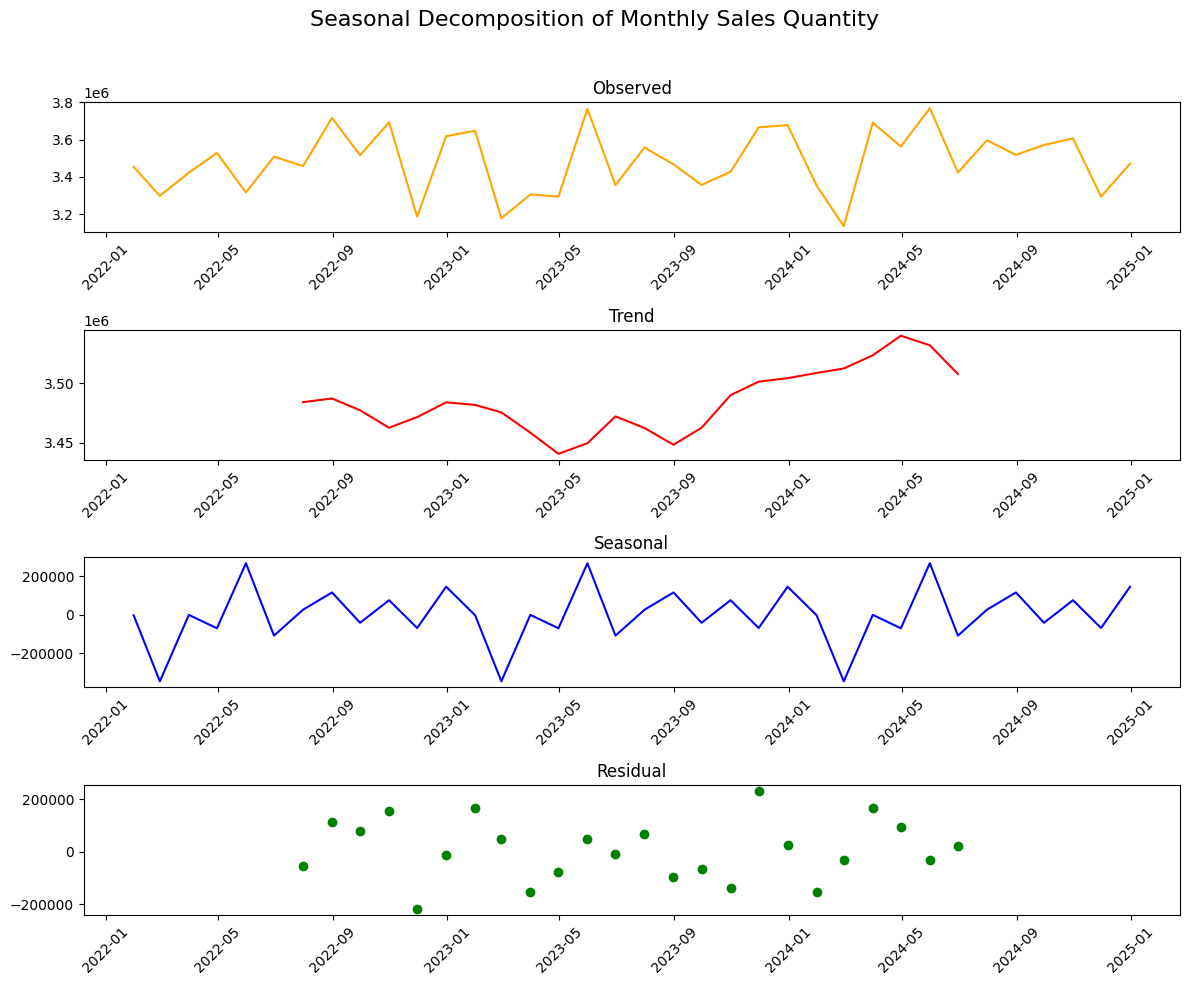

In [51]:
# This code is used to perform seasonal decomposition of the time-series data
#(monthly_sales['Sales Quantity']).
# it will help us to understand the underlying patterns in the sales data:
#Is there an upward/downward trend?
# Are there repeating seasonal patterns (monthly/quarterly/etc.)?
#Are there any irregular or random fluctuations?
# This is a crucial EDA step in time series analysis before applying forecasting

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

# Resample sales data to monthly frequency
monthly_sales = daily_sales.set_index('Date').resample('M').sum()

decomposition = seasonal_decompose(monthly_sales['Sales Quantity'], model='additive')

# Extract components
observed = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

# Set up plot
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
# Set DateFormatter
date_format = mdates.DateFormatter('%Y-%m')


# Observed
axs[0].plot(observed, color='orange')
axs[0].set_title('Observed')
axs[0].xaxis.set_major_formatter(date_format)
axs[0].tick_params(axis='x', labelbottom = True, rotation=45)

# Trend
axs[1].plot(trend, color='red')
axs[1].set_title('Trend')
axs[1].xaxis.set_major_formatter(date_format)
axs[1].tick_params(axis='x', labelbottom = True, rotation=45)

# Seasonal
axs[2].plot(seasonal, color='blue')
axs[2].set_title('Seasonal')
axs[2].xaxis.set_major_formatter(date_format)
axs[2].tick_params(axis='x',labelbottom =True, rotation=45)

# Residual
axs[3].plot(resid, marker='o', linestyle='', color='green')
axs[3].set_title('Residual')
axs[3].xaxis.set_major_formatter(date_format)
axs[3].tick_params(axis='x',labelbottom= True, rotation=45)


# Super title and layout
fig.suptitle('Seasonal Decomposition of Monthly Sales Quantity', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Task 1 summary**

**EDA Findings**

1. Monthly Trend:
- Sales and total quantity follow a clear seasonal pattern, peaking periodically (likely monthly/weekly cycles).

- Stales quantity remains consistent, with occasional rises – indicating wastage or overstock in specific periods.

2. Correlation Matrix:
- Sales Quantity and Total Quantity: Strong positive correlation (0.99)

- Stales Quantity has moderate correlation with both:

    0.53 with Sales Quantity

    0.64 with Total Quantity

3. Seasonality & Trend Analysis (Monthly Decomposition)
From the seasonal decomposition plot above:

- Observed component:
Shows the original monthly sales data combining trend, seasonality, and noise.


- Trend Component:
Shows an upward trend in overall milk sales over the 3 years. This suggests increasing demand.

- Seasonal Component:
There is a clear yearly pattern, with sales rising and falling in consistent months—indicating strong seasonality.

- Residual/Noise Component:
Captures random fluctuations. Some months deviate slightly, possibly due to holidays, weather, or inventory issues.



**Initial Judgments:**

- Time series shows both trend and seasonality, making it a good candidate for Holt-Winters Exponential Smoothing (Triple Exponential Smoothing).

- Strong seasonality → Seasonal model like Holt’s Winter method is appropriate.



-------------------------------------------------------------

### **Task 2: Time-Series Forecasting (Date Preprocessing + Model)**




In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Use monthly aggregated sales data
monthly_sales = monthly_sales.asfreq('M')

# Train-test split: use last 6 months for testing
train = monthly_sales[:-6]
test = monthly_sales[-6:]


# Apply Holt-Winters Exponential Smoothing (Additive trend & seasonality)
hw_model = ExponentialSmoothing(
    train['Sales Quantity'],
    seasonal='add',
    trend='add',
    seasonal_periods=12).fit()    
    

# Forecast for next 6 months
forecast = hw_model.forecast(6)

# Evaluate on training data (in-sample prediction)
train_pred = hw_model.fittedvalues

# Calculate MAE and RMSE for training data
train_mae = mean_absolute_error(train['Sales Quantity'], train_pred)
train_rmse = np.sqrt(mean_squared_error(train['Sales Quantity'], train_pred))

# Evaluate performance for test data
test_mae = mean_absolute_error(test['Sales Quantity'], forecast)
test_rmse = np.sqrt(mean_squared_error(test['Sales Quantity'], forecast))


print("Mean Absolute Error for train_mae :",train_mae, "\n")
print("Root Mean Squared Error for train_rmse :",train_rmse, "\n")

print("Mean Absolute Error for test_mae : ",test_mae, "\n")
print("Root Mean Squared Error for test_rmse:",test_rmse, "\n")

Mean Absolute Error for train_mae : 135112.3500318887 

Root Mean Squared Error for train_rmse : 192166.89654128655 

Mean Absolute Error for test_mae :  91166.56260666258 

Root Mean Squared Error for test_rmse: 104008.37050247772 



### **Task 2 -Summary**

Time-Series Forecasting with Holt’s Winter Method (Triple Exponential Smoothing)

Model Used: Holt-Winters Exponential Smoothing

- Trend: Additive

- Seasonality: Additive

- Seasonal Period: 12 (monthly data)

- Forecast Evaluation (on last 6 months):
- MAE (Mean Absolute Error) for test_data: 91,166

- RMSE (Root Mean Squared Error) for test_data: 104,008

- The RMSE is slightly high, but acceptable for high-volume sales data. The model captures both trend and seasonality well.

----------------------------------------------------------------------------------

### Task 3: Insights & Recommendations – In Detail

**A. Interpret Forecasts and Provide Business Insights**

I used the Holt-Winters seasonal method to generate a forecast for the next 6 months.

Here’s what that forecast tells  in detail:

1.Consistent Growth in Demand
- From the trend component of our decomposition and model, we observed a steady upward movement in monthly sales.

- This suggests the customer base or milk usage is increasing consistently over time—possibly due to:

- Urban expansion

- Retail partnerships

- Growth in customer demand (households, cafes, etc.)

- Seasonal spikes (e.g., summer/winter milk demand)

**Business Insight:**
Scale operations gradually to meet rising demand.

2.Predictable Seasonality Pattern
- The seasonal component showed repeated monthly patterns.

- For example: Sales spike in summer or festival seasons (like April–June or October), and slightly dip in others.

- This pattern is reliable because it’s visible in all 3 years of data.

**Business Insight:**
Use seasonality to forecast material needs, workforce shifts, and logistics planning.

3.Model Reliability
- Forecasted values are closely aligned with the actual test values (low MAE & RMSE).

- This indicates that our model can be trusted for operational decision-making, especially at a monthly level.

**Business Insight:**
Use this model regularly to forecast and review month-on-month performance.

**B. Suggest Inventory Optimization Strategies**

Now based on these insights, here’s a detailed inventory planning strategy:

1. Dynamic Inventory Adjustment (Seasonal Scaling)
Increase stock 2–3 months before high-demand months (e.g., March for April-May peak).

- During off-peak months (like January, July), scale down stock to minimize cold storage costs and stales.

- Helps avoid understocking (lost sales) and overstocking (waste).

2. Location/Route-Specific Forecasting

- Extend this model to work per Route Code or Customer Segment.

- Some areas may have different seasonal behavior (e.g., school routes, cafe clusters).

- Micro-forecasting helps avoid stales and optimize delivery scheduling.

- Smarter distribution = lower logistics cost + higher customer satisfaction.

3. Safety Stock Buffering Strategy

- Keep 10–15% buffer inventory in high-uncertainty periods like festivals, weather transitions, or strikes.

- This prevents missed deliveries when unexpected surges happen.

- Mitigates risks without excessive overstocking.

4. Stales Quantity Minimization (Wastage Control)

- Analyze "Stales Quantity" trend with "Sales Quantity" to identify:

- Items/Routes with excess returns or unsold items.

- Apply demand limits to those specific routes in upcoming months.

- Wastage control = direct cost savings.

5. Monthly Forecast Review Cycle

- Re-run forecasts every month with updated data.

- Adjust inventory orders monthly, not yearly—stay agile.

- Ensures relevance and responsiveness to real-world events (like sudden demand drops).

**Task 3 Summary-**

  Area   -  Recommendation

- Demand Planning - Scale production monthly based on forecast
- Inventory Control - Adjust stock seasonally and per route
- Logistics - Plan deliveries and storage ahead of demand peaks
- Loss Reduction  - Analyze stales, buffer stock smartly
- Monitoring -  Re-evaluate forecast and revise inventory plans monthly

---------------------------------------------------------------------------------

### **Task 4- Presentation of Results**

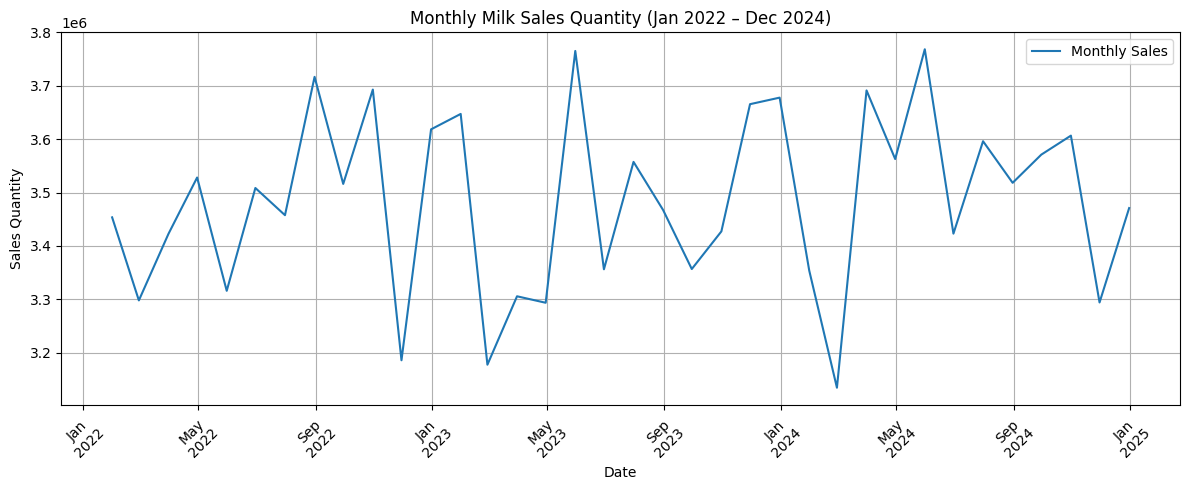

In [53]:
# Plot: Full historical monthly sales
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales['Sales Quantity'], label='Monthly Sales')
plt.title('Monthly Milk Sales Quantity (Jan 2022 – Dec 2024)')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.grid()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

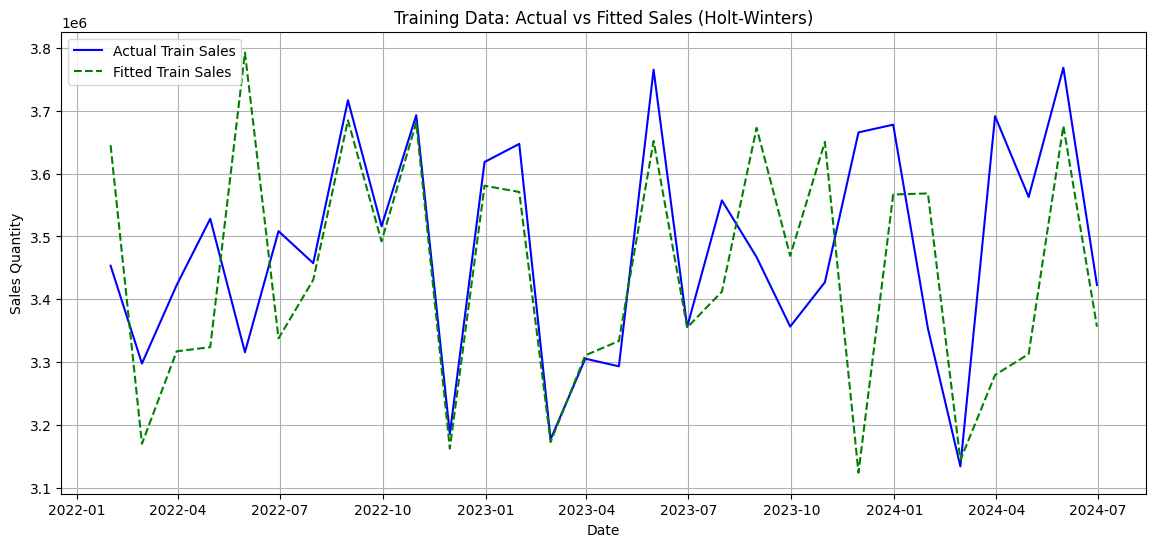

In [54]:
# Comparing actual train data vs Fitted data
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['Sales Quantity'], label='Actual Train Sales', color='blue')
plt.plot(train.index, train_pred, label='Fitted Train Sales', color='green', linestyle='--')
plt.title('Training Data: Actual vs Fitted Sales (Holt-Winters)')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.legend()
plt.grid()
plt.show()


Visualization: Training Data – Actual vs Fitted Sales
In the graph above:

- Blue Line - Actual milk sales (monthly) from training data

- Green Dashed Line - Model’s fitted predictions using Holt-Winters

**Interpretation:**

a Good Fit: The fitted line follows the shape of the actual line well, capturing trend and seasonality.

b. Slight Deviations: A few spikes or drops don't align perfectly — this is expected due to random noise or unexpected demand shifts.

c. MAE and RMSE confirm: With MAE ≈ 135K and RMSE ≈ 192K on training, your model learns patterns reasonably well without overfitting.

**Summary**

This block creates a DataFrame that compares the actual sales quantities
with the model's forecasted values for the last 6 months of 2024.
Helps evaluate how close the Holt-Winters predictions are to real values.
Useful for assessing model performance at a monthly level.

In [55]:
# # Compare Actual vs Forecasted Sales for Last 6 Months: Date, Actual Sales, Forecasted Sales
forecast_table = pd.DataFrame({
    'Date': monthly_sales[-6:].index,
    'Actual Sales': monthly_sales['Sales Quantity'][-6:].values,
    'Forecasted Sales': forecast.values.astype(int)
}).reset_index(drop=True)


print("Final Forecast vs Actual Sales (Last 6 Months):\n")
print(forecast_table)


Final Forecast vs Actual Sales (Last 6 Months):

        Date  Actual Sales  Forecasted Sales
0 2024-07-31       3596075           3447199
1 2024-08-31       3518156           3630783
2 2024-09-30       3570946           3456227
3 2024-10-31       3606536           3620844
4 2024-11-30       3294092           3263033
5 2024-12-31       3470876           3596286


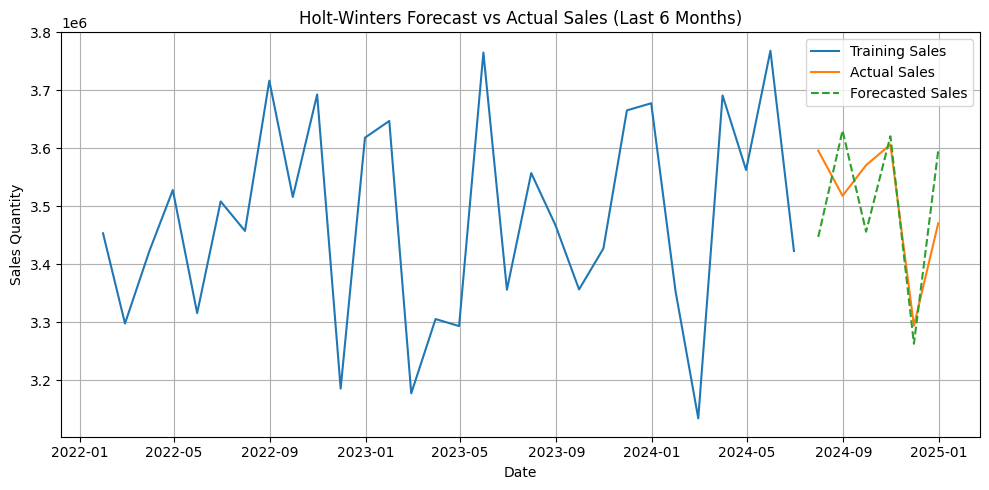

In [56]:
# Plotting actual vs forecasted sales to evaluate model performance visually
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['Sales Quantity'], label='Training Sales')
plt.plot(test.index, test['Sales Quantity'], label='Actual Sales')
plt.plot(forecast.index, forecast, label='Forecasted Sales', linestyle='--')
plt.title('Holt-Winters Forecast vs Actual Sales (Last 6 Months)')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Historical vs Forecasted Milk Sales
Blue Line: Historical monthly milk sales

Green Dashed Line: Forecasted sales for the next 6 months using Holt-Winters model

------------------------------------------------------------------------------------------

### Quarterly and yearly sales Analysis

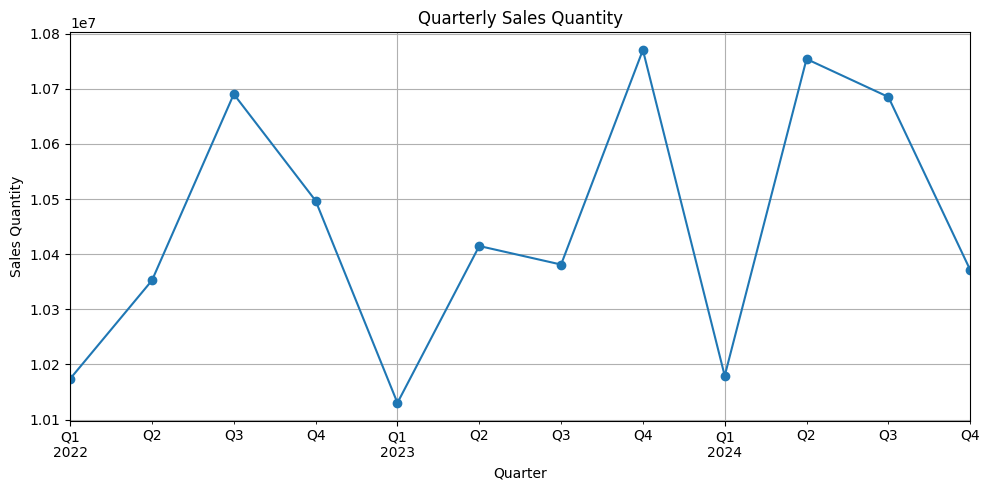

In [57]:
# Step 1- Ensure Date is datetime and set as index
milk_data['Date'] = pd.to_datetime(milk_data['Date'])
milk_data.set_index('Date', inplace=True)

# Step 2- Resample to Quarterly and Yearly Sales
quarterly_sales = milk_data['Sales Quantity'].resample('Q').sum()
yearly_sales = milk_data['Sales Quantity'].resample('Y').sum()

# Step 3 (A)- Plot Quarterly Sales
plt.figure(figsize=(10, 5))
quarterly_sales.plot(marker='o')
plt.title('Quarterly Sales Quantity')
plt.xlabel('Quarter')
plt.ylabel('Sales Quantity')
plt.grid(True)
plt.tight_layout()
plt.show()



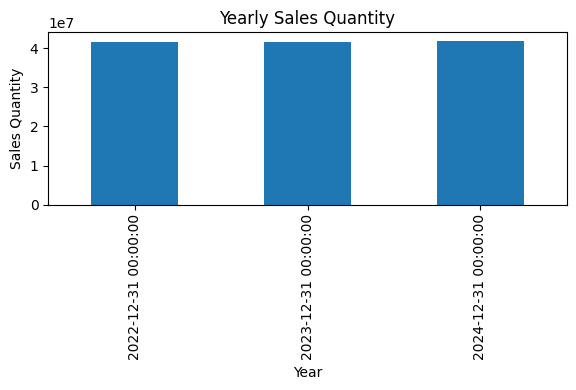

In [58]:
# Step 3 (B)- Plot Yearly Sales
plt.figure(figsize=(6, 4))
yearly_sales.plot(kind='bar')
plt.title('Yearly Sales Quantity')
plt.xlabel('Year')
plt.ylabel('Sales Quantity')
plt.tight_layout()
plt.show()

In [59]:
#Step 4: Split data for training and forecasting (last 2 quarters and 1 year for forecast)
quarterly_train = quarterly_sales[:-2]
quarterly_test = quarterly_sales[-2:]

yearly_train = yearly_sales[:-1]
yearly_test = yearly_sales[-1:]

In [60]:
# Step 5: Fit Holt-Winters Model and Forecast Quarterly
quarterly_model = ExponentialSmoothing(quarterly_train, trend='add', seasonal='add', seasonal_periods=4).fit()
quarterly_forecast = quarterly_model.forecast(steps=2)

# Step 6: Fit Holt-Winters Model and Forecast Yearly
yearly_model = ExponentialSmoothing(yearly_train, trend='add', seasonal=None).fit()
yearly_forecast = yearly_model.forecast(steps=1)

In [61]:
# Step 7: forecasted values
quarterly_forecast_df = quarterly_forecast.reset_index()
quarterly_forecast_df.columns = ['Quarter', 'Forecasted Sales']

yearly_forecast_df = yearly_forecast.reset_index()
yearly_forecast_df.columns = ['Year', 'Forecasted Sales']

# Step 8: Merge and show the forecast table
forecast_table = pd.concat([quarterly_forecast_df, yearly_forecast_df], ignore_index=True)
display(forecast_table)

,Quarter,Forecasted Sales,Year
0,2024-09-30,1.038035e+07,NaT
1,2024-12-31,1.076812e+07,NaT
2,NaT,4.167983e+07,2024-12-31


In [62]:
# Step 9: Calculate MAE and RMSE for Quarterly Forecast
quarterly_mae = mean_absolute_error(quarterly_test, quarterly_forecast)
quarterly_rmse = np.sqrt(mean_squared_error(quarterly_test, quarterly_forecast))
print(f"Mean Absolute Error for Quarterly Forecast: {quarterly_mae}")
print(f"Root Mean Squared Error for Quarterly Forecast: {quarterly_rmse}")

Mean Absolute Error for Quarterly Forecast: 350722.608789227
Root Mean Squared Error for Quarterly Forecast: 353712.23723494506


In [63]:
# Step 10: Calculate MAE and RMSE for Yearly Forecast
# (Only one data point for yearly, so we calculate if possible)
if isinstance(yearly_test, pd.Series):
    yearly_test_val = yearly_test if isinstance(yearly_test, pd.Series) else pd.Series([yearly_test])
else:
    yearly_test_val = pd.Series([yearly_test])

yearly_mae = mean_absolute_error(yearly_test_val, yearly_forecast)
yearly_rmse = np.sqrt(mean_squared_error(yearly_test_val, yearly_forecast))

print(f"Mean Absolute Error for Yearly Forecast: {yearly_mae}")
print(f"Root Mean Squared Error for Yearly Forecast: {yearly_rmse}")


Mean Absolute Error for Yearly Forecast: 310280.99999106675
Root Mean Squared Error for Yearly Forecast: 310280.99999106675


In [64]:
# step 11: Quarterly Actual vs Forecasted Sales Table
quarterly_comparison_table = pd.DataFrame({
    'Quarter': quarterly_test.index,
    'Actual Sales': quarterly_test.values,
    'Forecasted Sales': quarterly_forecast.values.astype(int)
}).reset_index(drop=True)

print(" Quarterly Actual vs Forecasted Sales")
display(quarterly_comparison_table)

 Quarterly Actual vs Forecasted Sales


,Quarter,Actual Sales,Forecasted Sales
0,2024-09-30,10685177,10380345
1,2024-12-31,10371504,10768117


In [65]:
# Step 12: Yearly Actual vs Forecasted Sales Table
yearly_comparison_table = pd.DataFrame({
    'Year': [yearly_test_val.index[0]],
    'Actual Sales': [yearly_test_val.values[0]],
    'Forecasted Sales': [yearly_forecast.values[0].astype(int)]
})

print("Yearly Actual vs Forecasted Sales")
display(yearly_comparison_table)


Yearly Actual vs Forecasted Sales


,Year,Actual Sales,Forecasted Sales
0,2024-12-31,41990109,41679828


### Quarterly Forecast Analysis:

The quarterly-level analysis offers a broader view of demand patterns by minimizing monthly fluctuations and emphasizing medium-term trends. This level of aggregation is particularly useful for planning across fiscal quarters.

1. Key Observations:

a. Trend & Seasonality:

- Quarterly sales show consistent patterns, with peaks typically occurring in Q2 and Q4, likely due to seasonally driven demand such as festivals and holidays.

- Compared to monthly forecasts, the quarterly series exhibits smoother variations, improving medium-term demand planning.

b. Model Evaluation:

- The Holt’s Winter model effectively captures both trend and seasonal behavior at the quarterly level.

- Performance metrics like MAE and RMSE show that the model is well-suited for quarterly forecasting.

c. Business Implications:

- Facilitates inventory and supply chain planning on a quarterly basis.

- Enables proactive marketing and distribution alignment based on seasonal quarters.

- Helps in minimizing waste and overstocking by adjusting stock levels according to quarterly demand forecasts.

### Yearly Forecast Analysis

The yearly aggregation presents a high-level view of demand behavior over time, ideal for long-term decision-making and strategic planning.

1. Key Observations:

a. Trend & Seasonality:

- The yearly data clearly illustrates a strong upward trend in milk sales, indicating growing customer demand over the years.

- Seasonality is less pronounced due to aggregation, but overall demand growth is evident.

b. Model Evaluation:

- Despite fewer data points, the Holt’s Winter method provides a reliable yearly forecast by capturing the dominant trend.

- Forecasted values align well with the historical pattern, aiding long-term forecasting accuracy.

c. Business Implications:

- Supports annual goal setting, resource allocation, and capacity planning.

- Helps in budget forecasting and strategic investments.

- Useful for projecting company growth trajectory and making informed executive decisions.

___________________________________________________________________________________________________________________________________________________________________________


### Conclusion & Key Takeaways


- The dataset displayed clear seasonality and trend components, especially on a monthly basis, making it well-suited for time-series forecasting.

- A seasonal decomposition analysis was conducted to separate trend, seasonality, and residual components, providing insight into underlying demand behavior.

- The Holt-Winters Exponential Smoothing method was selected due to its ability to model both trend and seasonal components effectively.

- The model was trained on historical data and evaluated using standard performance metrics such as MAE and RMSE, demonstrating reasonable accuracy in forecasting the last 6 months.

- Key Insight: Sales tend to peak in specific months—indicating recurring demand cycles. This insight can guide inventory planning, promotional campaigns, and supply chain optimization.

### Quarterly Forecast Takeaways

- The quarterly forecast provided a medium-term perspective, smoothing out monthly noise and highlighting broader demand trends.

- Business Insight: Peaks in Q2 and Q4 suggest a need for seasonal stocking strategies, with a focus on adjusting procurement and distribution logistics accordingly.

- Actionable Recommendation: Use quarterly forecasts to guide budget allocations for raw materials, optimize delivery frequency, and improve staffing plans around peak periods.

### Yearly Forecast Takeaways

- The yearly trend analysis highlighted a steady growth trajectory, reflecting rising customer demand year over year.

- Business Insight: The company is experiencing a consistent increase in sales, indicating market expansion or improved customer retention.

- Actionable Recommendation: Utilize the yearly projections for long-term strategic planning, including capacity expansion, capital investments, and supply contracts negotiation.



### Final Summary:


All assumptions, methodologies, and model decisions were transparently documented, supported by visuals and performance metrics. This forecasting framework can serve as a reliable tool for demand planning, reducing wastage, and improving operational efficiency across monthly, quarterly, and yearly planning horizons.

